In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
from xgboost import XGBClassifier
warnings.filterwarnings("ignore", category=UserWarning)

In [47]:
# Train the Stunting Model
y_stunting = df['Stunting']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_stunting, test_size=0.2, random_state=42)
model_stunting = RandomForestClassifier(n_estimators=100)
model_stunting.fit(X_train_s, y_train_s)

# Train the Wasting Model
y_wasting = df['Wasting']
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X, y_wasting, test_size=0.2, random_state=42)
model_wasting = RandomForestClassifier(n_estimators=100)
model_wasting.fit(X_train_w, y_train_w)

print("Both models are trained and ready for demo!")

Both models are trained and ready for demo!


Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7201
           1       1.00      1.00      1.00      8299
           2       1.00      1.00      1.00      2459
           3       1.00      1.00      1.00      2041

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

       AI MODEL BENCHMARKING REPORT          
Random Forest Accuracy : 100.00%
XGBoost Accuracy       : 100.00%


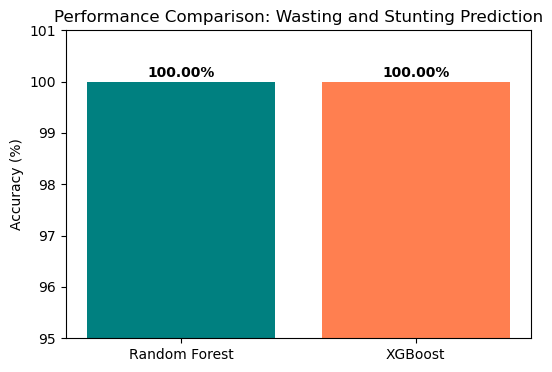

In [48]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print(classification_report(y_test, predictions))
df = pd.read_csv('stunting_wasting_dataset.csv')

# 2. Encode Inputs (Gender)
le_gender = LabelEncoder()
df['Jenis Kelamin'] = le_gender.fit_transform(df['Jenis Kelamin'])

X = df[['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']]

# 3. CRITICAL FOR XGBOOST: Encode the Output Classes into Numbers (0, 1, 2, 3)
le_wasting = LabelEncoder()
y_wasting_encoded = le_wasting.fit_transform(df['Wasting'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_wasting_encoded, test_size=0.2, random_state=42)

# 4. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds) * 100

# 5. Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_preds) * 100

# 6. Print the Comparison Benchmarking
print("=" * 45)
print("       AI MODEL BENCHMARKING REPORT          ")
print("=" * 45)
print(f"Random Forest Accuracy : {rf_accuracy:.2f}%")
print(f"XGBoost Accuracy       : {xgb_accuracy:.2f}%")
print("=" * 45)

# 7. Visualizing the Comparison
models = ['Random Forest', 'XGBoost']
accuracies = [rf_accuracy, xgb_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['teal', 'coral'])
plt.ylim(95, 101) # Zoom in close to 100% to see differences if any
plt.ylabel('Accuracy (%)')
plt.title('Performance Comparison: Wasting and Stunting Prediction')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

       AI MODEL BENCHMARKING REPORT          
Random Forest Accuracy : 100.00%
XGBoost Accuracy       : 100.00%


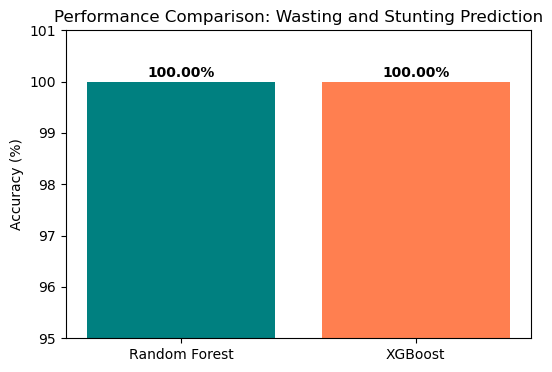

In [49]:
df = pd.read_csv('stunting_wasting_dataset.csv')

# 2. Encode Inputs (Gender)
le_gender = LabelEncoder()
df['Jenis Kelamin'] = le_gender.fit_transform(df['Jenis Kelamin'])

X = df[['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)']]

# 3. CRITICAL FOR XGBOOST: Encode the Output Classes into Numbers (0, 1, 2, 3)
le_wasting = LabelEncoder()
y_wasting_encoded = le_wasting.fit_transform(df['Wasting'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_wasting_encoded, test_size=0.2, random_state=42)

# 4. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds) * 100

# 5. Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_preds) * 100

# 6. Print the Comparison Benchmarking
print("=" * 45)
print("       AI MODEL BENCHMARKING REPORT          ")
print("=" * 45)
print(f"Random Forest Accuracy : {rf_accuracy:.2f}%")
print(f"XGBoost Accuracy       : {xgb_accuracy:.2f}%")
print("=" * 45)

# 7. Visualizing the Comparison
models = ['Random Forest', 'XGBoost']
accuracies = [rf_accuracy, xgb_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['teal', 'coral'])
plt.ylim(95, 101) # Zoom in close to 100% to see differences if any
plt.ylabel('Accuracy (%)')
plt.title('Performance Comparison: Wasting and Stunting Prediction')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

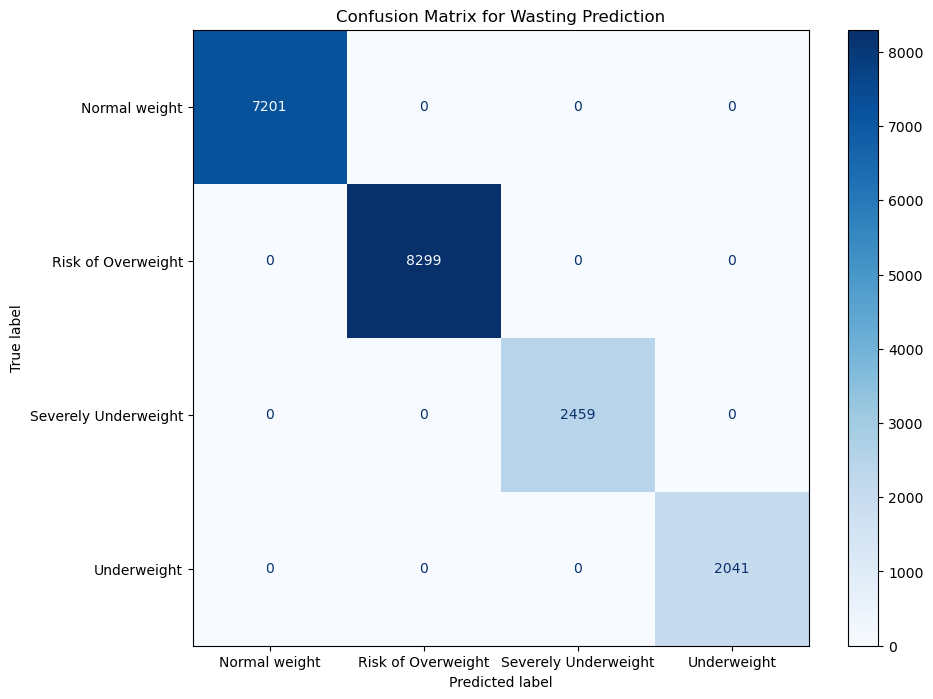

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(model_wasting, X_test_w, y_test_w, cmap='Blues', ax=ax)
plt.title("Confusion Matrix for Wasting Prediction")
plt.show()

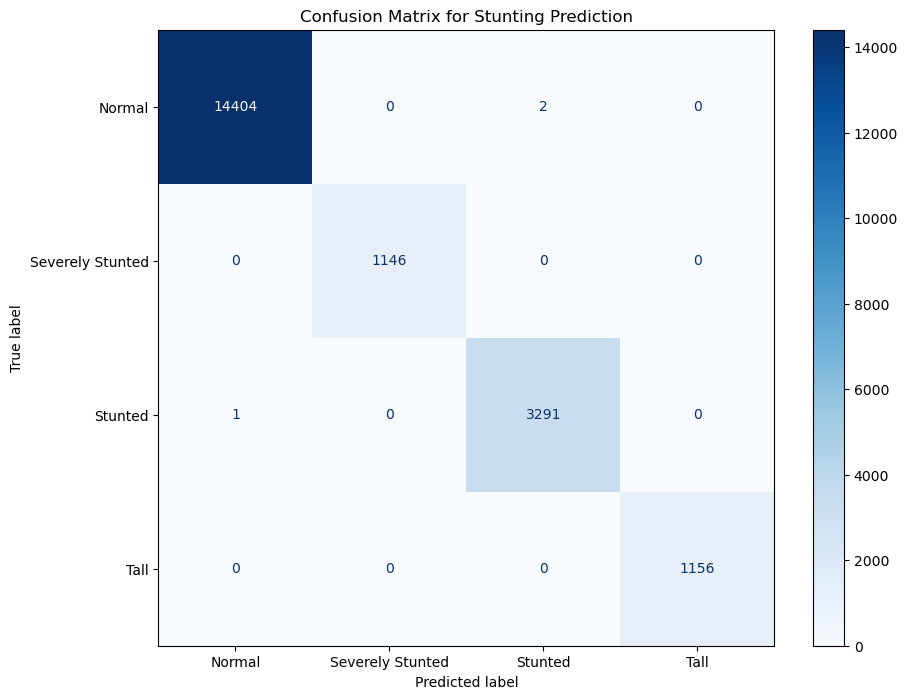

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(model_stunting, X_test_s, y_test_s, cmap='Blues', ax=ax)
plt.title("Confusion Matrix for Stunting Prediction")
plt.show()

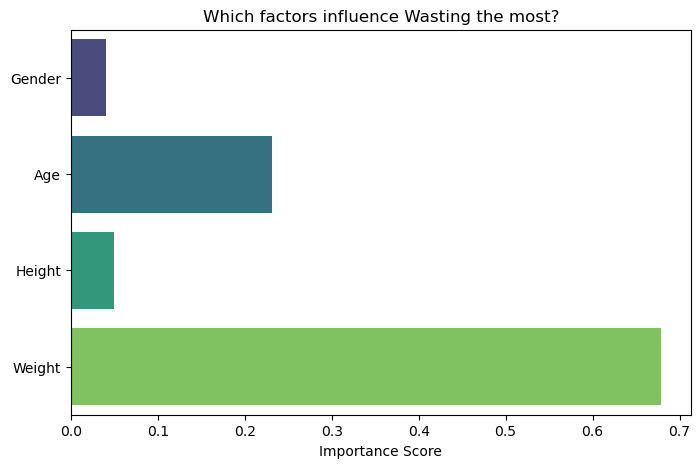

In [52]:
# --- FEATURE IMPORTANCE CELL ---
importances = model_wasting.feature_importances_
feature_names = ['Gender', 'Age', 'Height', 'Weight']

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Which factors influence Wasting the most?")
plt.xlabel("Importance Score")
plt.show()

In [53]:
# --- MASTER DEMO: COMPLETE DIAGNOSIS ---

# 1. Input child data
name = "Budi"
gender = "Laki-laki" 
age = 18            # months
height = 90      # cm (Try a low height like 55.0 to see 'Severely Stunted')
weight = 10        # kg (Try a low weight like 4.0 to see 'Severely Underweight')

# 2. Process data
gender_enc = le_gender.transform([gender])[0]
child_features = [[gender_enc, age, height, weight]]

# 3. Get both predictions
res_stunting = model_stunting.predict(child_features)[0]
res_wasting = model_wasting.predict(child_features)[0]

# 4. Show the "Bio-Report"
print(f"--- BIOLOGICAL ASSESSMENT FOR {name.upper()} ---")
print(f"Status: {gender}, {age} months old")
print(f"Growth: {height} cm / {weight} kg")
print("-" * 40)
print(f"STUNTING DIAGNOSIS : {res_stunting}")
print(f"WASTING DIAGNOSIS  : {res_wasting}")
print("-" * 40)

--- BIOLOGICAL ASSESSMENT FOR BUDI ---
Status: Laki-laki, 18 months old
Growth: 90 cm / 10 kg
----------------------------------------
STUNTING DIAGNOSIS : Normal
WASTING DIAGNOSIS  : Normal weight
----------------------------------------
